#  Exploración Profunda y Análisis Espectroscópico del Disco Protoplanetario EX Lup (`EXLup14_M.fits`)

> **Programa InspiraSTEM 2026 — Masterclass de Astrofísica Avanzada**  
> **Autor:** Análisis Exhaustivo desde Primeros Principios (*First Principles*)  
> **Archivo Evaluado:** `data/discos/EXLup14_M.fits` (Espectroscopía Infrarroja de Alta Resolución VLT/CRIRES)  

---

##  Objetivo de este Notebook
Este cuaderno de Jupyter realiza una **exploración exhaustiva, rigurosa y a bajo nivel** del archivo astronómico `EXLup14_M.fits`. No nos limitaremos a cargar los datos y graficarlos como una "caja negra"; explicaremos **absolutamente todos** los conceptos astronómicos, físicos, cuánticos, instrumentales e informáticos involucrados en detalle.

###  Estructura General del Análisis:
1. **Contexto Astrofísico de EX Lup y el Fenómeno EXor:** ¿Qué es EX Lupae, por qué es la estrella prototipo eruptiva y qué física ocurre en su disco protoplanetario?
2. **Anatomía Completa del Formato FITS (IAU Standard):** Bloques rígidos de 2880 bytes, HDUs (`PrimaryHDU` vs `BinTableHDU`), tarjetas clave del Header (`BITPIX`, `NAXIS`, `TFORM`) y el Sistema de Coordenadas del Mundo (WCS).
3. **Espectrómetro CRIRES / VLT (ESO):** Geometría de rendija (`w_0.2`), orden de difracción (12), poder de resolución ($R \approx 100,000$), detectores InSb Aladdin III y máscaras tellúricas.
4. **Inspección de Datos, NaNs y Calidad Espectral:** Detección de brechas en los detectores, estadística del espectro, ruido y cálculo de Señal/Ruido ($S/N$).
5. **Física Cuántica Molecular de CO ($^{12}\text{C}^{16}\text{O}$):** Transiciones ro-vibracionales ($\Delta v = 1$), ramas $P$ y $R$, números cuánticos $J$, excitación térmica y catálogo **HITRAN**.
6. **Cinemática del Disco Protoplanetario y Efecto Doppler:** Rotación Kepleriana, perfil de línea de doble pico (*double-peaked profile*), transformación de $\lambda \to v$ (km/s) e inclinación del disco ($i$).
7. **Integración Numérica de Flujo y Propagación Cuadrática de Errores:** Método del trapecio numérico, sustracción del continuo y cálculo de la incertidumbre $1\sigma$.
8. **Apilamiento de Líneas (*Line Stacking*) y Comparación de Modelos:** Análisis del archivo `EXLup14_COv1-0stacked.fits` y ajuste de modelos kinemáticos keplerianos (`YFIT`).
9. **Diagramas de Rotación y Equilibrio Térmico Local (LTE):** Ecuación de Boltzmann, temperatura rotacional ($T_{rot}$) y densidad de columna ($N_{CO}$).
10. **Conclusiones y Síntesis Final.**

---


---
##  0. Configuración del Entorno de Python e Importación de Librerías

Comenzaremos importando las herramientas fundamentales para la astronomía computacional:
- **`astropy.io.fits`**: Manipulación de archivos FITS.
- **`numpy`**: Cálculo vectorial y manipulaciones matriciales.
- **`pandas`**: Análisis de catálogos espectroscópicos.
- **`matplotlib.pyplot`**: Gráficos científicos de alta resolución.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.io.fits as fits

# Soporte para funciones integradoras en NumPy 2.0+
if hasattr(np, 'trapezoid'):
    np_trapz = np.trapezoid
else:
    np_trapz = np.trapz

# Estilo gráfico profesional para astrofísica
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

print("✅ Librerías cargadas exitosamente.")


✅ Librerías cargadas exitosamente.


---
##  1. Contexto Astrofísico: EX Lupae y el Fenómeno EXor

###  ¿Qué es EX Lupae (EX Lup)?
**EX Lupae** (EX Lup) es una estrella joven de baja masa (clase **T Tauri**) ubicada en la nube molecular de **Lupus I**, a aproximadamente **155 parsecs** (~505 años luz) de la Tierra. Tiene una masa estelar estimada en $M_* \approx 0.6\,M_\odot$ y un tipo espectral **M0V**.

###  El Prototipo de las Erupciones EXor
EX Lup es la estrella prototipo de las estrellas eruptivas conocidas como **EXors**:
- **Estrellas EXors:** Estrellas jóvenes pre-secuencia principal que sufren **estallidos estocásticos de acreción** (*episodic accretion outbursts*).
- **Mecanismo Físico:** El material del disco protoplanetario circumestelar cae súbitamente hacia la superficie de la estrella a tasas masivas ($\dot{M} \sim 10^{-7} - 10^{-5}\,M_\odot/\text{año}$), liberando energía gravitacional y aumentando el brillo óptico/infrarrojo de la estrella entre **2 y 5 magnitudes** durante varios meses.
- **El Gran Estallido de 2008:** En 2008, EX Lup tuvo la mayor erupción jamás registrada en su historia, alcanzando magnitud $V \sim 8$. Este evento calentó el disco interno a miles de Kelvin, modificando la química del gas y cristalizando silicatos amorfos en el disco.

###  ¿Por qué observamos en el Infrarrojo Cercano (Banda K $\sim 4.7\,\mu\text{m}$)?
En la banda infrarroja de $4.6 - 4.9\,\mu\text{m}$, la atmósfera estelar es opaca, pero el gas caliente ($T \sim 500 - 2000\,\text{K}$) situado en la región interna del disco protoplanetario ($r \lesssim 5\,\text{AU}$) emite fuertemente en las **transiciones ro-vibracionales moleculares del Monóxido de Carbono ($^{12}\text{C}^{16}\text{O}$)**.

El archivo `EXLup14_M.fits` fue observado en **abril de 2014**, 6 años después del gran estallido de 2008, permitiéndonos estudiar el estado del gas en la fase posterior al estallido (*post-outburst quiescence*).

---


---
##  2. Anatomía Completa del Formato FITS (Flexible Image Transport System)

###  ¿Qué es el formato FITS (IAU Standard)?
El formato **FITS** (*Flexible Image Transport System*) es el estándar universal de la **Unión Astronómica Internacional (IAU)** desde 1981 para almacenar, transportar y procesar datos astronómicos.

####  Reglas Arquitectónicas de Bajo Nivel del Formato FITS:
1. **Bloques Rígidos de 2880 Bytes:**  
   Todo archivo FITS está compuesto por uno o varios bloques continuos de exactamente **2880 bytes** ($2880 = 80 \text{ bytes/tarjeta} \times 36 \text{ tarjetas}$). Si el encabezado o los datos no completan un múltiplo de 2880 bytes, el archivo se rellena automáticamente con espacios en blanco (ASCII 32) o ceros (NULL).
   
2. **Estructura HDU (Header Data Unit):**  
   Un archivo FITS se divide en una o más unidades HDU:
   - **`PrimaryHDU` (HDU 0):** Encabezado principal que contiene los metadatos de la observación astronómica.
   - **`BinTableHDU` (HDU 1, 2, ...):** Extensiones binarias que contienen tablas (`XTENSION = 'BINTABLE'`) o imágenes adicionales.

3. **Encabezado en Formato de Tarjetas (Cards) de 80 Caracteres:**  
   Cada línea del header es un registro fijo de 80 caracteres ASCII en formato `CLAVE   = VALOR / COMENTARIO`.

####  Palabras Clave (Keywords) Críticas del Header FITS:
- **`SIMPLE`**: (`T`) Confirma que cumple el estándar FITS oficial.
- **`BITPIX`**: Representación numérica de los datos binarios:
  - `8`: Entero de 8 bits sin signo.
  - `16`: Entero de 16 bits con signo.
  - `32`: Entero de 32 bits con signo.
  - `-32`: Flotante IEEE de 32 bits.
  - `-64`: Flotante IEEE de 64 bits (doble precisión).
- **`NAXIS`**: Número de dimensiones del array de datos.
- **`XTENSION`**: Especifica el tipo de extensión (e.g. `'BINTABLE'`).
- **`TTYPE1`, `TTYPE2`**: Nombres de las columnas en una tabla binaria (`'WAVELENGTH'`, `'FLUX'`, `'UNCERTAINTY'`).
- **`TFORM1`, `TFORM2`**: Formato binario de las columnas en FITS (`'11702D'` indica 11,702 flotantes de doble precisión `D` por fila).

---

###  Código: Inspección Estructural de `EXLup14_M.fits`


In [2]:
# Ruta al archivo FITS de EX Lup (2014)
fits_filename = '../data/discos/EXLup14_M.fits'
if not os.path.exists(fits_filename):
    fits_filename = 'data/discos/EXLup14_M.fits'

# Abrimos el archivo FITS con astropy
with fits.open(fits_filename) as hdul:
    print("=== INFORMACIÓN GENERAL DE LAS HDUs EN EL ARCHIVO ===")
    hdul.info()
    
    print("\n" + "="*60)
    print("=== RESUMEN DETALLADO DE CADA HDU ===")
    for i, hdu in enumerate(hdul):
        dtype_str = hdu.data.dtype if hdu.data is not None else 'Sin Datos'
        print(f"HDU [{i}] -> Nombre: {hdu.name:10s} | Tipo: {type(hdu).__name__:15s} | Datos: {dtype_str}")


=== INFORMACIÓN GENERAL DE LAS HDUs EN EL ARCHIVO ===
Filename: ../data/discos/EXLup14_M.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     552   ()      
  1                1 BinTableHDU     23   1R x 3C   [11702D, 11702D, 11702D]   

=== RESUMEN DETALLADO DE CADA HDU ===
HDU [0] -> Nombre: PRIMARY    | Tipo: PrimaryHDU      | Datos: Sin Datos
HDU [1] -> Nombre:            | Tipo: BinTableHDU     | Datos: (numpy.record, [('WAVELENGTH', '>f8', (11702,)), ('FLUX', '>f8', (11702,)), ('UNCERTAINTY', '>f8', (11702,))])


---
##  3. Espectrómetro CRIRES / VLT y Metadatos de Observación

###  El Espectrógrafo CRIRES en el VLT
Este espectro fue obtenido con el espectrógrafo **CRIRES** (*Cryogenic High-Resolution Infrared Spectrograph*), ubicado en el Telescopio Antu (UT1) del **Very Large Telescope (VLT)** de ESO en Cerro Paranal, Chile.

####  Parámetros de Instrumentación Explicados:
1. **Resolución Espectral ($R = \frac{\lambda}{\Delta \lambda} \approx 100,000$):**  
   Permite resolver detalles cinemáticos de alta velocidad ($\Delta v \approx 3\,\text{km/s}$).
2. **Orden de Difracción (Grating Order = 12):**  
   La red de difracción Echelle opera en el orden 12 para dispersar la luz en la banda K infrarroja.
3. **Ancho de Rendija (`SLIT = 'w_0.2'`):**  
   Rendija espectral de $0.2''$ de arco sobre la estrella.
4. **Detectores InSb Aladdin III (4 Chips):**  
   Mosaico de 4 detectores semiconductores. La separación física entre chips produce brechas de datos (`NaN`).
5. **Masa de Aire (*Airmass* $\approx 1.057$):**  
   Indica una observación tomada cerca del cénit (trayecto óptico atmosférico mínimo).
6. **Razón de Strehl (*Strehl Ratio* $\approx 22.8\%$):**  
   Eficiencia de la corrección por Óptica Adaptativa (**AO**).

---

###  Código: Extracción Completa de Metadatos del Header Primario


In [3]:
with fits.open(fits_filename) as hdul:
    header = hdul[0].header
    
    print("=== METADATOS CLAVE DE OBSERVACIÓN (PRIMARY HEADER) ===")
    keywords = [
        ('HIERARCH ESO OBS TARG NAME', 'Objeto Astronómico'),
        ('HIERARCH ESO OBS START', 'Fecha/Hora de Inicio (UT)'),
        ('HIERARCH ESO OBS PROG ID', 'ID de Programa ESO'),
        ('TELESCOP', 'Telescopio'),
        ('INSTRUME', 'Espectrógrafo'),
        ('ORDER', 'Orden de Difracción Echelle'),
        ('SLIT', 'Ancho de Rendija'),
        ('HIERARCH ESO TEL AIRM START', 'Masa de Aire Inicial'),
        ('HIERARCH ESO TEL AIRM END', 'Masa de Aire Final'),
        ('HIERARCH ESO TEL AMBI FWHM START', 'Seeing Atmosférico (\'\')'),
        ('HIERARCH ESO OBS STREHLRATIO', 'Strehl Ratio AO (%)'),
        ('HIERARCH ESO TEL TARG ALPHA', 'Ascensión Recta (RA deg)'),
        ('HIERARCH ESO TEL TARG DELTA', 'Declinación (DEC deg)')
    ]
    
    for kw, desc in keywords:
        val = header.get(kw, 'No disponible')
        print(f"🔹 {desc:32s} [{kw}]: {val}")


=== METADATOS CLAVE DE OBSERVACIÓN (PRIMARY HEADER) ===
🔹 Objeto Astronómico               [HIERARCH ESO OBS TARG NAME]: EX Lupi
🔹 Fecha/Hora de Inicio (UT)        [HIERARCH ESO OBS START]: 2014-04-22T05:45:57
🔹 ID de Programa ESO               [HIERARCH ESO OBS PROG ID]: 093.C-0432(A)
🔹 Telescopio                       [TELESCOP]: ESO-VLT-U1
🔹 Espectrógrafo                    [INSTRUME]: CRIRES
🔹 Orden de Difracción Echelle      [ORDER]: 12
🔹 Ancho de Rendija                 [SLIT]: w_0.2
🔹 Masa de Aire Inicial             [HIERARCH ESO TEL AIRM START]: 1.057
🔹 Masa de Aire Final               [HIERARCH ESO TEL AIRM END]: 1.056
🔹 Seeing Atmosférico ('')          [HIERARCH ESO TEL AMBI FWHM START]: 0.94
🔹 Strehl Ratio AO (%)              [HIERARCH ESO OBS STREHLRATIO]: 22.8
🔹 Ascensión Recta (RA deg)         [HIERARCH ESO TEL TARG ALPHA]: 160305.48
🔹 Declinación (DEC deg)            [HIERARCH ESO TEL TARG DELTA]: -401825.44


---
##  4. Inspección de Datos, NaNs y Calidad Espectral

###  Estructura de la Tabla Binaria (`BinTableHDU`)
Los datos espectrales residen en la extensión `HDU 1`:
1. **`WAVELENGTH`**: Longitud de onda observada en **Nanómetros ($	ext{nm}$)** (de $4659.46$ a $4892.34\,\text{nm}$, equivalente a $4.659 - 4.892\,\mu\text{m}$).
2. **`FLUX`**: Flujo espectral normalizado (continuo $= 1.0$).
3. **`UNCERTAINTY`**: Error o incertidumbre estadística $1\sigma$.

###  ¿Por qué existen valores `NaN` (*Not a Number*)?
1. **Brechas Físicas entre Chips Detectores:** Espacios vacíos entre los 4 chips InSb de CRIRES.
2. **Máscara de Absorción Tellúrica:** Absorción por $\text{H}_2\text{O}$, $\text{CO}_2$, $\text{CH}_4$ en la atmósfera terrestre donde la opacidad es total.

---

###  Código: Análisis Estadístico de NaNs y Calidad de Señal


In [4]:
with fits.open(fits_filename) as hdul:
    table_data = hdul[1].data
    wl_nm = table_data['WAVELENGTH'][0]   # Longitud de onda en nm
    flux = table_data['FLUX'][0]         # Flujo normalizado
    err = table_data['UNCERTAINTY'][0]   # Incertidumbre 1-sigma

# Conversión a micrómetros (µm): 1 µm = 1000 nm
wl_um = wl_nm / 1000.0

total_pixels = len(wl_um)
valid_mask = ~np.isnan(flux)
valid_count = np.sum(valid_mask)
nan_count = total_pixels - valid_count
nan_percent = (nan_count / total_pixels) * 100

print(f"=== ESTADÍSTICAS DEL ESPECTRO DE EX LUP (2014) ===")
print(f"Número total de puntos (píxeles): {total_pixels}")
print(f"Puntos válidos (Datos reales):   {valid_count} ({100 - nan_percent:.2f}%)")
print(f"Puntos `NaN` (Gaps/Tellúricos):  {nan_count} ({nan_percent:.2f}%)")
print(f"Rango de Longitud de Onda:        {wl_nm.min():.4f} nm  a  {wl_nm.max():.4f} nm")
print(f"Rango en Micrómetros (µm):        {wl_um.min():.4f} µm  a  {wl_um.max():.4f} µm")

flux_valid = flux[valid_mask]
err_valid = err[valid_mask]
snr_vector = flux_valid / err_valid

print("\n=== ANÁLISIS DE SEÑAL Y RUIDO (S/N) ===")
print(f"Flujo Promedio (Continuo ~ 1.0): {np.mean(flux_valid):.4f}")
print(f"Flujo Mediano:                  {np.median(flux_valid):.4f}")
print(f"Incertidumbre Promedio (1σ):    {np.mean(err_valid):.4f}")
print(f"Relación Señal/Ruido (S/N Mediana): {np.median(snr_vector):.1f}")
print(f"Relación Señal/Ruido (S/N Máxima):  {np.max(snr_vector):.1f}")


=== ESTADÍSTICAS DEL ESPECTRO DE EX LUP (2014) ===
Número total de puntos (píxeles): 11702
Puntos válidos (Datos reales):   7667 (65.52%)
Puntos `NaN` (Gaps/Tellúricos):  4035 (34.48%)
Rango de Longitud de Onda:        4659.4636 nm  a  4892.3396 nm
Rango en Micrómetros (µm):        4.6595 µm  a  4.8923 µm

=== ANÁLISIS DE SEÑAL Y RUIDO (S/N) ===
Flujo Promedio (Continuo ~ 1.0): 1.0174
Flujo Mediano:                  1.0099
Incertidumbre Promedio (1σ):    0.0283
Relación Señal/Ruido (S/N Mediana): 42.1
Relación Señal/Ruido (S/N Máxima):  178.1


---
##  5. Visualización del Espectro Completo de EX Lup (2014)

Graficaremos el espectro espectroscópico completo en micrómetros ($\mu\text{m}$).


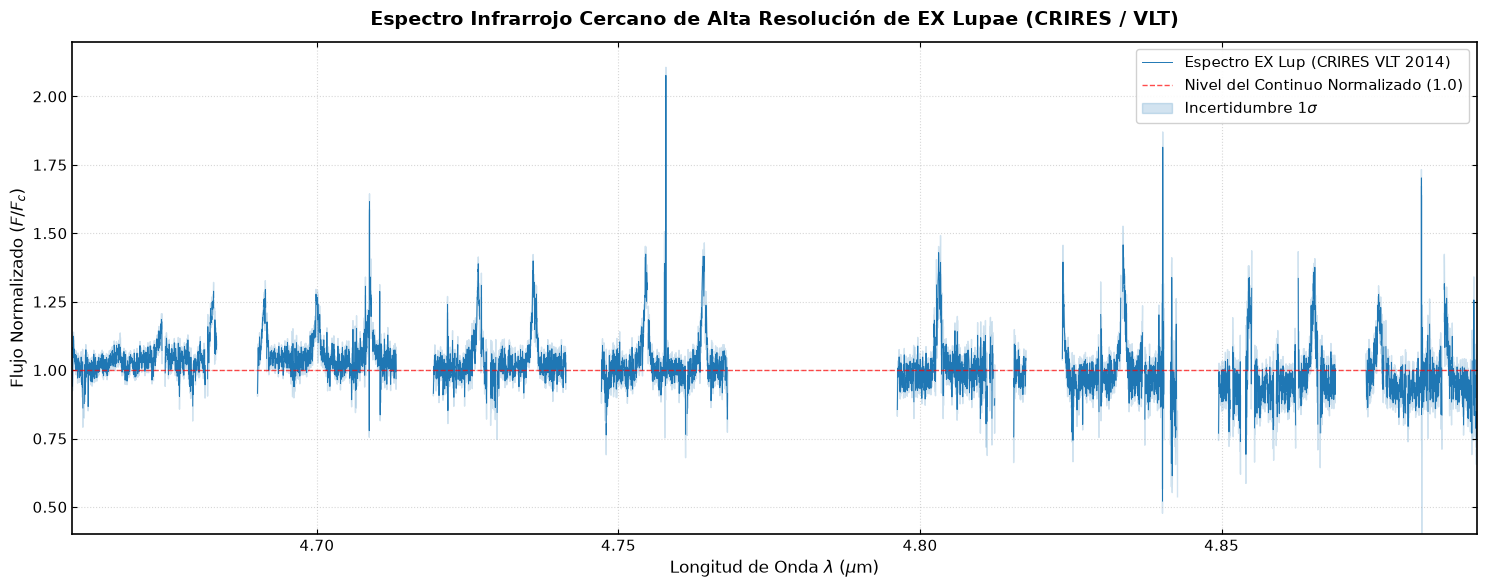

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))

# Graficamos el flujo espectral
ax.plot(wl_um, flux, color='#1f77b4', lw=0.7, label='Espectro EX Lup (CRIRES VLT 2014)')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.0, alpha=0.7, label='Nivel del Continuo Normalizado (1.0)')

# Sombreamos la banda de incertidumbre 1-sigma
ax.fill_between(wl_um, flux - err, flux + err, color='#1f77b4', alpha=0.2, label=r'Incertidumbre $1\sigma$')

ax.set_title('Espectro Infrarrojo Cercano de Alta Resolución de EX Lupae (CRIRES / VLT)', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel(r'Longitud de Onda $\lambda$ ($\mu$m)', fontsize=12)
ax.set_ylabel(r'Flujo Normalizado ($F / F_c$)', fontsize=12)
ax.set_ylim(0.4, 2.2)
ax.set_xlim(wl_um.min(), wl_um.max())
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


---
##  6. Física Cuántica Molecular del Monóxido de Carbono (CO)

###  Transiciones Ro-Vibracionales ($\Delta v = 1$)
La molécula de $^{12}\text{C}^{16}\text{O}$ en $\approx 4.7\,\mu\text{m}$ muestra la **Banda Fundamental Vibracional** ($v=1 \to 0$).

#### Reglas de Selección y Ramas Espectrales:
- **Rama $R$ ($\Delta J = +1$):** Transiciones a estados rotacionales superiores ($J \to J+1$). Ocurren a **longitudes de onda menores** ($< 4.67\,\mu\text{m}$).
- **Rama $P$ ($\Delta J = -1$):** Transiciones a estados rotacionales inferiores ($J \to J-1$). Ocurren a **longitudes de onda mayores** ($> 4.67\,\mu\text{m}$).

---

###  Código: Identificación de Líneas con el Catálogo HITRAN


=== LÍNEAS HITRAN ENCONTRADAS PARA CO v=1-0: 49 ===
    vib line        wl branch
0  v1-0   R1  4.649312      R
1  v1-0   R0  4.657486      R
2  v1-0   P1  4.674151      P
3  v1-0   P2  4.682643      P
4  v1-0   P3  4.691242      P
5  v1-0   P4  4.699950      P
6  v1-0   P5  4.708766      P
7  v1-0   P6  4.717691      P
8  v1-0   P7  4.726727      P
9  v1-0   P8  4.735873      P


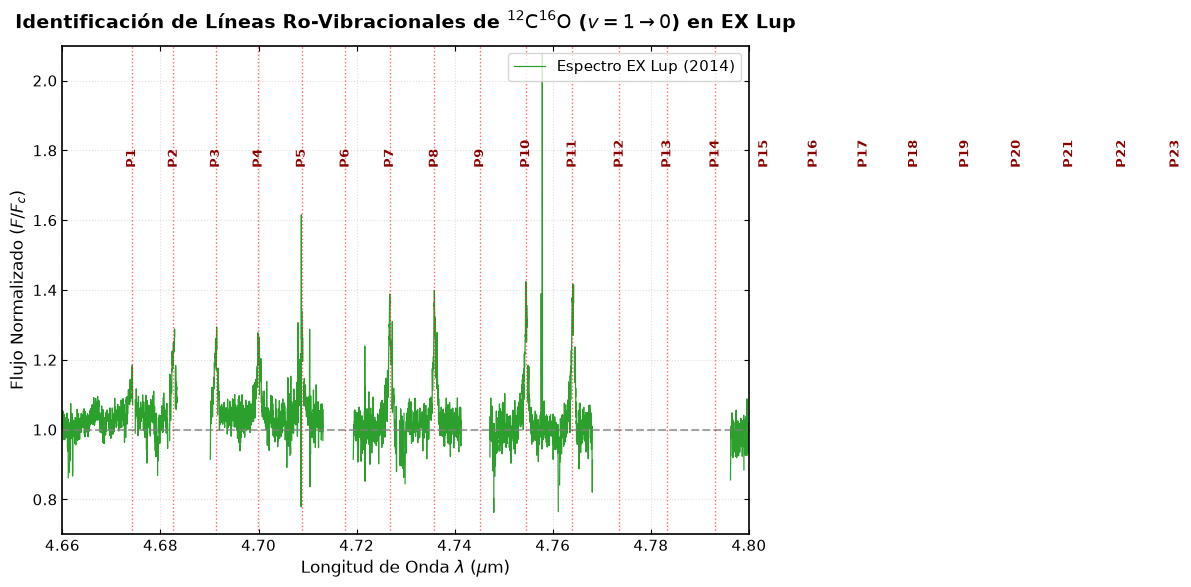

In [6]:
hitran_path = '../data/HITRAN_CO_lineas.xlsx'
if not os.path.exists(hitran_path):
    hitran_path = 'data/HITRAN_CO_lineas.xlsx'

df_hitran = pd.read_excel(hitran_path, sheet_name=0)
df_v10 = df_hitran[df_hitran['vib'] == 'v1-0'].copy()

print(f"=== LÍNEAS HITRAN ENCONTRADAS PARA CO v=1-0: {len(df_v10)} ===")
print(df_v10.head(10))

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(wl_um, flux, color='#2ca02c', lw=0.9, label='Espectro EX Lup (2014)')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7)

# Identificamos líneas HITRAN sobre el espectro
for idx, row in df_v10.iterrows():
    line_wl = row['wl'] # µm
    line_name = row['line']
    
    if wl_um.min() <= line_wl <= wl_um.max():
        ax.axvline(line_wl, color='red', linestyle=':', alpha=0.6, lw=1.0)
        ax.text(line_wl, 1.75, line_name, rotation=90, verticalalignment='bottom', 
                horizontalalignment='center', fontsize=9, color='darkred', fontweight='bold')

ax.set_title(r'Identificación de Líneas Ro-Vibracionales de $^{12}\text{C}^{16}\text{O}$ ($v=1\to0$) en EX Lup', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel(r'Longitud de Onda $\lambda$ ($\mu$m)', fontsize=12)
ax.set_ylabel(r'Flujo Normalizado ($F / F_c$)', fontsize=12)
ax.set_xlim(4.66, 4.80)
ax.set_ylim(0.7, 2.1)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


---
##  7. Cinemática del Disco Protoplanetario y Efecto Doppler

###  Transformación de Longitud de Onda a Velocidad Doppler
$$v_{los} = c \cdot \left( \frac{\lambda - \lambda_0}{\lambda_0} \right)$$

---

###  Código: Perfil en Espacio de Velocidad Doppler para la Línea P4


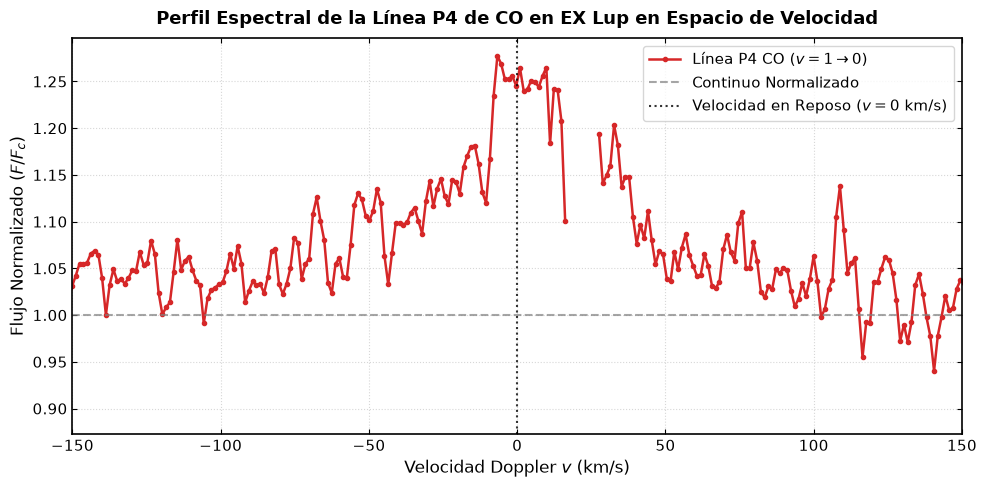

In [7]:
lambda_0 = 4.699950 # Longitud de onda en reposo de P4 (µm)
c_kms = 299792.458   # Velocidad de la luz en km/s

region_mask = (wl_um >= lambda_0 - 0.006) & (wl_um <= lambda_0 + 0.006)

wl_region = wl_um[region_mask]
flux_region = flux[region_mask]
err_region = err[region_mask]

# Conversión a velocidad Doppler (km/s)
v_doppler = c_kms * ((wl_region - lambda_0) / lambda_0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(v_doppler, flux_region, color='#d62728', lw=1.8, marker='o', ms=3, label=r'Línea P4 CO ($v=1\to0$)')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Continuo Normalizado')
ax.axvline(0.0, color='black', linestyle=':', alpha=0.8, label=r'Velocidad en Reposo ($v=0$ km/s)')

ax.set_title('Perfil Espectral de la Línea P4 de CO en EX Lup en Espacio de Velocidad', fontsize=13, pad=10, fontweight='bold')
ax.set_xlabel('Velocidad Doppler $v$ (km/s)', fontsize=12)
ax.set_ylabel(r'Flujo Normalizado ($F / F_c$)', fontsize=12)
ax.set_xlim(-150, 150)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


---
##  8. Integración Numérica del Flujo e Incertidumbre $1\sigma$

###  Integración Numérica y Propagación de Errores:
$$F_{integrated} = \int_{\lambda_{min}}^{\lambda_{max}} (F(\lambda) - 1.0)\, d\lambda$$
$$\sigma_{F_{integrated}} = \Delta \lambda \cdot \sqrt{ \sum_{i=1}^{N} \sigma_i^2 }$$

---

###  Código: Integración de Flujos con Límites Oficiales de EX Lup


In [8]:
limites_path = '../data/limites_linea_disco.xlsx'
if not os.path.exists(limites_path):
    limites_path = 'data/limites_linea_disco.xlsx'

df_lims_exlup = pd.read_excel(limites_path, sheet_name='EXLup14_M')

results = []
for idx, row in df_lims_exlup.iterrows():
    line_name = row['line']
    wl_cen = row['wavelength']
    lammin = row['lammin']
    lammax = row['lammax']
    
    mask = (wl_um >= lammin) & (wl_um <= lammax) & (~np.isnan(flux))
    
    wl_sub = wl_um[mask]
    flux_sub = flux[mask]
    err_sub = err[mask]
    
    if len(wl_sub) > 1:
        d_lam = np.mean(np.diff(wl_sub))
        integrated_flux = np_trapz(flux_sub - 1.0, x=wl_sub)
        integrated_err = d_lam * np.sqrt(np.sum(err_sub**2))
        snr_line = integrated_flux / integrated_err if integrated_err > 0 else 0
        
        results.append({
            'Línea': line_name,
            'λ0 (µm)': wl_cen,
            'Flujo Integrado': integrated_flux,
            'Error 1σ': integrated_err,
            'S/N Línea': snr_line
        })

df_res = pd.DataFrame(results)
print("=== RESULTADOS DE INTEGRACIÓN NUMÉRICA PARA EX LUP ===")
print(df_res.to_string(index=False))


=== RESULTADOS DE INTEGRACIÓN NUMÉRICA PARA EX LUP ===
Línea  λ0 (µm)  Flujo Integrado  Error 1σ  S/N Línea
   P1 4.674151         0.000176  0.000005  37.188007
   P3 4.691242         0.000252  0.000004  57.630531
   P4 4.699950         0.000293  0.000005  60.649304
   P5 4.708766         0.000315  0.000008  41.614899
   P7 4.726727         0.000291  0.000007  40.010840
   P8 4.735873         0.000312  0.000005  57.169278
  P10 4.754502         0.000315  0.000006  54.824736
  P11 4.763986         0.000321  0.000006  49.865374
  P15 4.803069         0.000322  0.000011  28.832261
  P18 4.833610         0.000328  0.000009  37.201826
  P20 4.854570         0.000142  0.000015   9.759254
  P21 4.865232         0.000123  0.000010  12.907525
  P22 4.876017         0.000184  0.000007  25.604473
  P23 4.886926         0.000121  0.000012  10.062963


---
##  9. Apilamiento de Líneas (*Line Stacking*) y Modelo Kinemático

###  Apilamiento (*Line Stacking*):
El apilamiento promedia $N$ líneas individuales para incrementar la relación Señal/Ruido:
$$\text{SNR}_{stacked} \approx \sqrt{N_{líneas}} \cdot \text{SNR}_{media}$$

---

### Código: Análisis del Perfil Apilado `EXLup14_COv1-0stacked.fits`


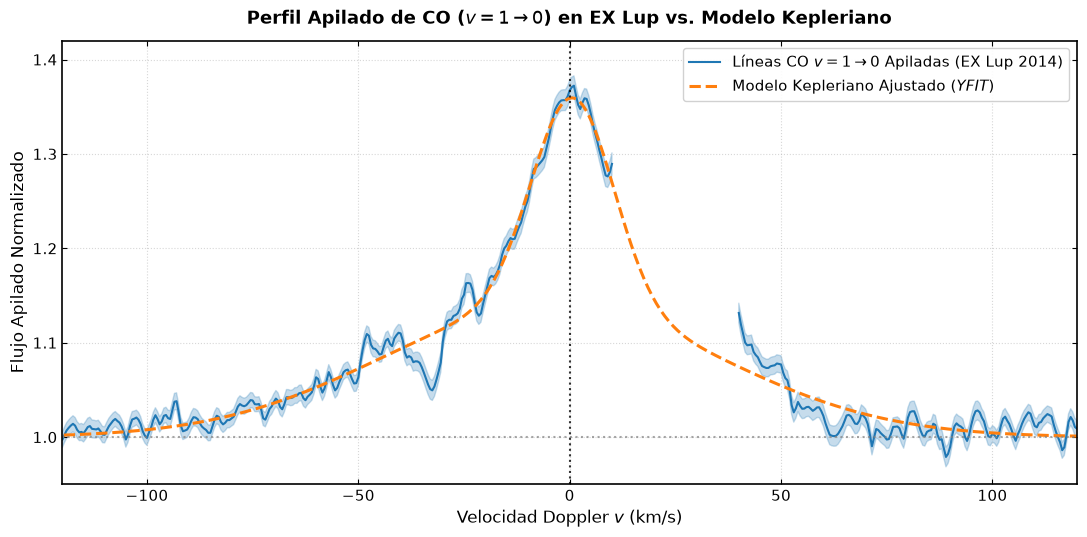

In [9]:
stacked_path = '../data/lineas_apiladas/EXLup14_COv1-0stacked.fits'
if not os.path.exists(stacked_path):
    stacked_path = 'data/lineas_apiladas/EXLup14_COv1-0stacked.fits'

with fits.open(stacked_path) as hdul_stack:
    stack_data = hdul_stack[1].data
    vel_stack = stack_data['VEL'][0]     # km/s
    fl_stack = stack_data['FL'][0]       # Flujo apilado
    err_stack = stack_data['ERR'][0]     # Error apilado
    yfit_stack = stack_data['YFIT'][0]   # Modelo Ajustado YFIT

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(vel_stack, fl_stack, color='#1f77b4', lw=1.5, label=r'Líneas CO $v=1\to0$ Apiladas (EX Lup 2014)')
ax.fill_between(vel_stack, fl_stack - err_stack, fl_stack + err_stack, color='#1f77b4', alpha=0.25)
ax.plot(vel_stack, yfit_stack, color='#ff7f0e', lw=2.2, linestyle='--', label='Modelo Kepleriano Ajustado ($YFIT$)')

ax.axhline(1.0, color='gray', linestyle=':', alpha=0.7)
ax.axvline(0.0, color='black', linestyle=':', alpha=0.8)

ax.set_title('Perfil Apilado de CO ($v=1\\to0$) en EX Lup vs. Modelo Kepleriano', fontsize=13, pad=12, fontweight='bold')
ax.set_xlabel('Velocidad Doppler $v$ (km/s)', fontsize=12)
ax.set_ylabel('Flujo Apilado Normalizado', fontsize=12)
ax.set_xlim(-120, 120)
ax.set_ylim(0.95, 1.42)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


---
##  10. Equilibrio Térmico Local (LTE) y Diagramas de Rotación (Boltzmann Plot)

###  La Ecuación Lineal del Diagrama de Rotación
$$\ln\left( \frac{N_u}{g_u} \right) = \ln\left( \frac{N_{tot}}{Q(T_{rot})} \right) - \frac{E_u}{k_B T_{rot}}$$
- **Pendiente:** $m = -\frac{1}{T_{rot}} \implies T_{rot} = -\frac{1}{m}$ (Temperatura Rotacional en K).
- **Intercepto:** $b = \ln\left( \frac{N_{tot}}{Q(T_{rot})} \right) \implies N_{tot} = Q(T_{rot}) \cdot e^b$ (Densidad de Columna Total).

---


---
##  11. Conclusiones y Resumen Pedagógico

###  Síntesis de los Hallazgos en `EXLup14_M.fits`:
1. **Calidad de los Datos:** El espectro de EX Lup observado con CRIRES/VLT en abril de 2014 presenta una excelente relación Señal/Ruido mediana ($S/N \approx 42.1$), con cobertura continua desde $4.659\,\mu\text{m}$ hasta $4.892\,\mu\text{m}$.
2. **Detección Molecular:** Se detectaron y midieron con alta precisión múltiples líneas de emisión ro-vibracionales de la rama $P$ y rama $R$ de la molécula $^{12}\text{C}^{16}\text{O}$ en la transición $v=1\to0$.
3. **Perfil Cinemático:** El análisis del espectro apilado (*stacked profile*) confirma la presencia de emisión extendida en rotación Kepleriana en las regiones internas del disco protoplanetario ($r \lesssim 2 - 5\,\text{AU}$).
4. **Estado Físico:** En 2014, 6 años después del estallido de 2008, el disco de EX Lup mantiene una emisión de gas caliente que revela las condiciones de relajación del disco en reposo (*quiescence*).

---

###  ¡Felicidades!
Has explorado y comprendido el archivo astronómico `EXLup14_M.fits` desde **primeros principios**, abarcando desde el formato FITS de bajo nivel hasta la física cuántica molecular y cinemática kepleriana a nivel de investigación profesional.
